In [2]:
# import required libraries for mall customer segmentation using hierarchical clustering
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


In [3]:
data = pd.read_csv('../data/Mall_Customers.csv')
data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
data.isna().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

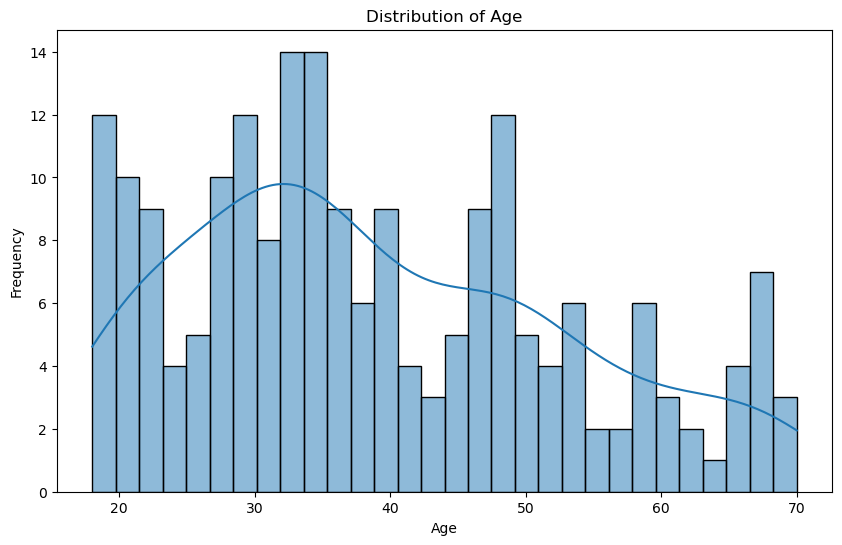

In [6]:
# drop the 'CustomerID' column as it is not useful for clustering
data.drop('CustomerID', axis=1, inplace=True)

# visualize the distribution of 'Age' column
plt.figure(figsize=(10, 6))
sns.histplot(data['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


In [7]:
# selecting features for clustering
X = data[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# standardize the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

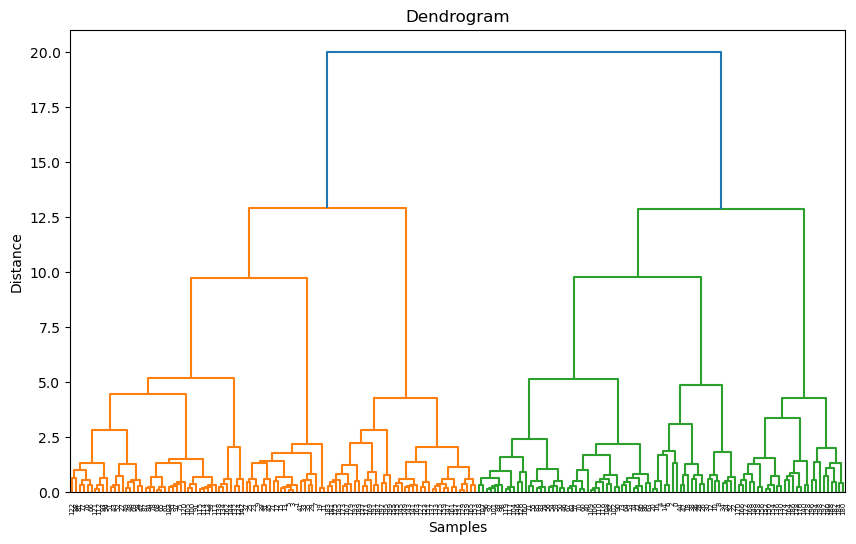

In [8]:
# hierarchical clustering using Ward's method
linked = linkage(X, method='ward')

# plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrogram')
plt.xlabel('Samples')
plt.ylabel('Distance')
plt.show()


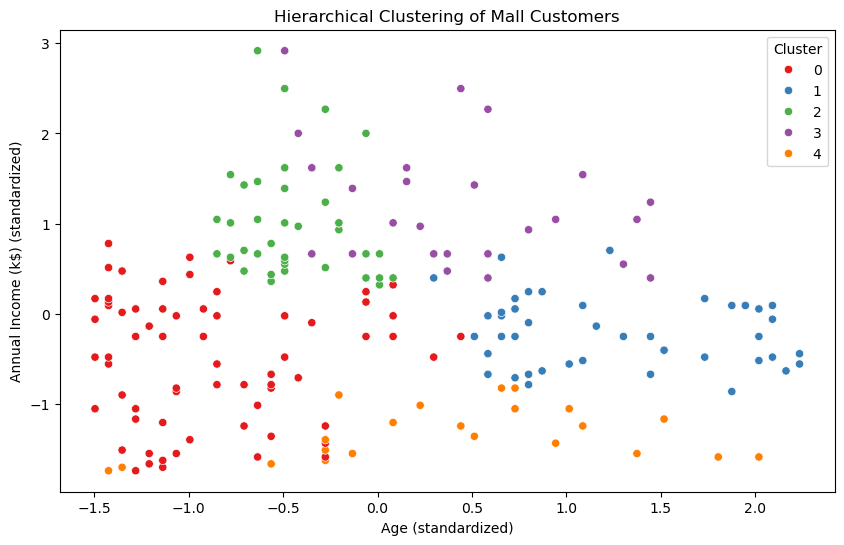

In [11]:
# fit the hierarchical clustering model with 5 clusters
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
y_hc = hc.fit_predict(X)

# visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y_hc, palette='Set1')
plt.title('Hierarchical Clustering of Mall Customers')
plt.xlabel('Age (standardized)')
plt.ylabel('Annual Income (k$) (standardized)')
plt.legend(title='Cluster')
plt.show()